---
title: "Monthly Air Temperature Regression from Satellite Land Surface Temperature" 
subtitle: "A Destination Earth / DEFAIR use case : MSG SEVIRI × EDLST × ERA5-Land."
author: "Author: Alejandro Fonseca (EUMETSAT/Starion)"
tags: [DEFAIR, HDA, MSG, SEVIRI, EDLST, ERAJ]
license: MIT
copyright: "© 2026 EUMETSAT"
---

<!-- Optional: Add a JupyterHub launch link here. If you don’t have one, you can remove this block. -->

<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/template1.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>


### Contents

This notebook estimates the **mean 2 m air temperature of June 2026** over Central and Western
Europe from satellite observations of surface temperature alone, using the DEFAIR AI-ready data
framework end to end. It is the condensed edition of the same use case: identical science and
identical final grid, but the data pipeline is expressed in far fewer steps by letting DEFAIR's
multi-file reading and its AlignmentPlugin do the heavy lifting.

### What DEFAIR is used for

Turning three heterogeneous raw satellite/reanalysis files per day (for 30 days) into one clean,
gridded, aligned cube that an AI/ML model can consume directly. Concretely:

- **`Readers`** : `msg15nat`, `metop_edlst`, `era5grib` — one per source.
- **Multi-file (wildcard) reading** : `Dataset.from_source("s3://.../msg/*.nat", ...)` reads a
  whole month of scenes in one call, concatenated along `time`.
- **`content_filter`** : keep only the variable of interest (IR 10.8 µm, LST, 2t).
- **`spatial_filter`** : crop the base source to the study area (once, not three times).
- **`AlignmentPlugin`** : reproject all three sources onto one pinned reference grid, derive the
  common extent, and merge them into a single daily cube — reprojection is performed internally,
  so no per-source reprojection step is needed.
- **`temporal_aggregate`** : collapse the 30-day cube into one June-mean image (once, on the
  cube, not three times on the separate sources).

### How it works

Everything goes through one object, `Dataset.from_source(path, reader=...)`, and transformations
are chained by name, each returning a new dataset. Operations are lazy (Dask) until `.compute()`
is called. Every raw file is streamed directly from an S3 bucket, nothing is downloaded to local
disk. The bucket is populated previously of this use case, is the only data source. The output grid is pinned with a
`ReferenceGrid`, which makes every run pixel-identical and deterministic. Every transformation is
recorded in the dataset's CF history, keeping the processing chain traceable.

### Usefulness

The three sources are radically different formats: geostationary native binary (MSG), sinusoidal
global HDF5 of 18001×36000 pixels (EDLST), and reanalysis GRIB with a [0°, 360°] longitude
convention (ERA5-Land). DEFAIR reads and processes all three through the same API, without the
user handling each format's internals. The heterogeneous grids land on identical coordinates
inside a single alignment call, so the final merge requires no extra resampling.

### Data sources

- **Study period:** June 2026 (30 days)
- **Area of interest:** Central and Western Europe, lat 36–54° N, lon −10–15° E

| Variable | Source | Sampling | Role | Format |
|---|---|---|---|---|
| IR 10.8 µm brightness temperature | MSG SEVIRI (geostationary) | 1 scene/day, ~12:00 UTC | Feature (x₁) | .nat |
| Land surface temperature (LST) | EDLST (Metop, LSA SAF), DAY product | 1 image/day | Feature (x₂) | HDF5 |
| 2 m air temperature | ERA5-Land (reanalysis) | 1 value/day, 12:00 UTC | Label (y) | .grib |

- **Methods:** Both satellite sources measure **land surface temperature (LST)** .The radiometric
  temperature of soil, vegetation or asphalt as seen by an infrared sensor from space. Most
  applications, however, care about the **2 m air temperature**: the temperature a person actually
  breathes and the one weather stations report. A Random Forest regression learns the monthly-mean
  mapping from the two satellite surface temperatures to the reanalysis air temperature, with an
  honest spatial validation split.

## Setup & Imports

In [62]:
%pip install --user --quiet cartopy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [63]:
# Standard library
import os
from getpass import getpass

# Third-party
import boto3
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from affine import Affine

# DEFAIR API
from defair.logging import setup_logging
from defair_data.core import Dataset
from defair_ops.transformations.alignment import AlignmentPlugin
from defair_ops.transformations.reprojection import ReferenceGrid

setup_logging(log_level="WARNING")  # "INFO", "WARNING", "ERROR"

### Configuration

Study area, study period, and the S3 bucket holding the raw-data cache.  
S3 credentials are entered at runtime and never stored in the notebook.

In [64]:
# Study area: Central & Western Europe
LAT_MIN, LAT_MAX = 36.0, 54.0
LON_MIN, LON_MAX = -10.0, 15.0

# Study period: June 2026, one scene per day at noon
YEAR, MONTH = "2026", "06"
days = [f"{d:02d}" for d in range(1, 31)]  # "01" .. "30"

# Output folder for figures and results
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# ================================================================================
# S3 raw-data cache: edit these three lines to point at a different S3 object store
S3_ENDPOINT = "https://s3.central.data.destination-earth.eu"
S3_BUCKET = "datalake-demo-data"
S3_PREFIX = "defair-demo-data/"
# ================================================================================

S3_ACCESS_KEY = getpass("S3 access key: ")
S3_SECRET_KEY = getpass("S3 secret key: ")

# boto3 client: used only to inventory the cache before processing
s3_client = boto3.session.Session(
    aws_access_key_id=S3_ACCESS_KEY,
    aws_secret_access_key=S3_SECRET_KEY,
).client("s3", endpoint_url=S3_ENDPOINT)  # endpoint_url is required, otherwise boto3 targets AWS

# Passed to Dataset.from_source(..., source="s3", source_kwargs=...) so DEFAIR can stream
# each raw file from the bucket
S3_SOURCE_KWARGS = {
    "aws_access_key_id": S3_ACCESS_KEY,
    "aws_secret_access_key": S3_SECRET_KEY,
    "endpoint_url": S3_ENDPOINT,
}

# Quick inventory of the cache: 30 objects expected per source
for source in ["msg", "edlst", "era5"]:
    response = s3_client.list_objects_v2(Bucket=S3_BUCKET, Prefix=S3_PREFIX + source + "/")
    count = len(response.get("Contents", []))
    print(f"{source}: {count} objects in the bucket")

S3 access key:  ········
S3 secret key:  ········


msg: 30 objects in the bucket
edlst: 30 objects in the bucket
era5: 30 objects in the bucket


### The common target grid, pinned as a ReferenceGrid

All three sources will be brought onto one common grid: EPSG:4326 at 0.05° resolution (~5.5 km),
covering the study area.

There are two ways to tell DEFAIR what that grid is. The usual one is to pass a CRS string
(`"EPSG:4326"`) plus a resolution, and let the framework work out the exact output geometry from
the inputs. The one used here is to declare the grid **explicitly** as a `ReferenceGrid`: its
CRS, its pixel size, its corner position, and its dimensions, all fixed in advance.

Pinning the grid this way has two practical advantages:

1. **Determinism.** Every run of the notebook produces exactly the same grid, pixel for pixel.
   The auto-computed path cannot guarantee this, since it derives the geometry from the inputs.
2. **A cleaner run.** With the geometry fixed in advance, DEFAIR skips the step where it probes
   each input to work out an output geometry. 

In [65]:
# The project grid: 0.05 deg pixels, upper-left corner at (LON_MIN, LAT_MAX).
# resolution: 25 deg of longitude / 0.05 = 500 columns, 18 deg of latitude / 0.05 = 360 rows.
TARGET_RESOLUTION = 0.05  # degrees (~5.5 km)

grid_width = round((LON_MAX - LON_MIN) / TARGET_RESOLUTION)   # -> 500
grid_height = round((LAT_MAX - LAT_MIN) / TARGET_RESOLUTION)  # -> 360


project_grid = ReferenceGrid(
    crs="EPSG:4326",
    transform=Affine(TARGET_RESOLUTION, 0.0, LON_MIN, 0.0, -TARGET_RESOLUTION, LAT_MAX),
    width=grid_width,
    height=grid_height,
)
print(f"Reference grid: {project_grid.crs} | {grid_width} x {grid_height} "
      f"pixels @ {TARGET_RESOLUTION} deg")

Reference grid: EPSG:4326 | 500 x 360 pixels @ 0.05 deg


### Helper function

One helper reused across the notebook: `plot_temperature_map` renders a 2D field over the study
area with coastlines and borders.

In [66]:
def plot_temperature_map(data_2d, title, cbar_label, cmap="inferno"):
    """Plot a 2D lat/lon field over the study area with coastlines and borders."""
    # Clip the colour scale to the 2nd-98th percentile so a few outliers
    # do not flatten the contrast
    vmin = float(np.nanpercentile(data_2d.values, 2))
    vmax = float(np.nanpercentile(data_2d.values, 98))

    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        data_2d["lon"].values,
        data_2d["lat"].values,
        data_2d.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
        shading="auto",
    )
    ax.coastlines(resolution="50m", linewidth=1.0, color="white")
    ax.add_feature(cfeature.BORDERS, linewidth=0.7, edgecolor="white")
    ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5, linestyle="--", color="white")
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)
    plt.tight_layout()
    plt.show()

## MSG SEVIRI: brightness temperature (feature x₁)

The whole month (30 images) is read in **one call**. `Dataset.from_source` natively supports wildcard
patterns: the glob is expanded server-side against the bucket, every matched `.nat` file is
opened in parallel, and the scenes are concatenated along `time`. The stack is then reduced to
the IR 10.8 µm channel and cropped to the study area. The crop is applied once, to the whole
stack, and this is the only per-source spatial crop in the notebook: MSG acts as the *base*
dataset of the alignment later on, so its extent defines the common study-area bounds.

Two details specific to the MSG reader under DEFAIR:

- `calibration="auto"` is mandatory under DEFAIR, and the reason is the order of
  operations inside the reader. The MSG file carries 11 channels of two physical kinds:
  *solar* channels (visible/near-IR), whose calibrated quantity is reflectance, and *thermal*
  channels (infrared), whose calibrated quantity is brightness temperature. The reader validates
  the requested calibration against **all 11 channels before any filtering happens** ,so asking
  for `"brightness_temperature"` fails, because that quantity is physically meaningless for the
  three solar channels. `"auto"` resolves this by calibrating each channel according to its own type;
  the channel we keep, `ir_10.8`, is thermal and therefore receives brightness temperature, numerically identical to what the scalar
  request would have produced.
- The bucket stores one scene per day under a deterministic date key (`msg/{YYYYMMDD}.nat`). 

In [67]:
# One call reads the whole month: the glob pattern matches every .nat object of the study
# period in the bucket, and the scenes are concatenated along "time".
msg_stack = Dataset.from_source(
    f"s3://{S3_BUCKET}/{S3_PREFIX}msg/{YEAR}{MONTH}*.nat",
    reader="msg15nat",
    calibration="auto",              # rc5: scalar "brightness_temperature" fails; "auto" does not
    use_channel_names=True,
    source="s3",
    source_kwargs=S3_SOURCE_KWARGS,
)

# Keep only the IR 10.8 um channel, then crop the whole stack to the study area
msg_stack = msg_stack.transform("content_filter", include_vars=["ir_10.8"])
msg_stack = msg_stack.transform(
    "spatial_filter",
    lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX,
)

# Diagnostics: one time step per day of June expected
n_scenes = msg_stack.data.sizes["time"]
print(f"\nMSG stack: {n_scenes} / {len(days)} daily scenes")
print("Dims:", dict(msg_stack.data.sizes))
print("Time range:", msg_stack.data.time.values[0], "->", msg_stack.data.time.values[-1])

2026-07-28 10:52:51 | WARNING  | [2442ff42] defair_data.readers.msg15._msg15_xarray_backend:open_dataset:448 - No start_time found in headers or filename
2026-07-28 10:52:51 | WARNING  | [72764956] defair_data.readers.msg15._msg15_xarray_backend:open_dataset:448 - No start_time found in headers or filename
2026-07-28 10:52:51 | WARNING  | [1a072054] defair_data.readers.msg15._msg15_xarray_backend:open_dataset:448 - No start_time found in headers or filename
2026-07-28 10:52:51 | WARNING  | [cd61b11c] defair_data.readers.msg15._msg15_xarray_backend:open_dataset:448 - No start_time found in headers or filename
2026-07-28 10:52:51 | WARNING  | [91e72118] defair_data.readers.msg15._msg15_xarray_backend:open_dataset:448 - No start_time found in headers or filename
2026-07-28 10:52:51 | WARNING  | [cf3e44e1] defair_data.readers.msg15._msg15_xarray_backend:open_dataset:448 - No start_time found in headers or filename
2026-07-28 10:52:52 | WARNING  | [2442ff42] defair_data.dask_manager:release


MSG stack: 30 / 30 daily scenes
Dims: {'time': 30, 'y': 394, 'x': 717}
Time range: 2026-06-01T12:00:00.000000000 -> 2026-06-30T12:00:00.000000000


## EDLST: land surface temperature (feature x₂)

Like MSG and ERA5, the whole month is read in **one wildcard call**.

For this to work, the bucket stores the EDLST files under their **original product names**
(`S-LSA_-HDF5_LSASAF_M##-AVHR_EDLST-DAY_GLOBE_YYYYMMDDhhmm`): the reader derives each field's
date from that name, which is what allows the scenes to be stacked along `time`. This is a good
general practice when populating an object store for DEFAIR (keep the original product names,
since readers derive metadata from them). One deliberate edit was applied to the keys: the
timestamp is set to `1200` (noon) instead of the product's original midnight, so each daily
field carries the same 12:00 UTC label as the other two sources.

The environment variable below makes DEFAIR read the files one at a time instead of in
parallel. 

**Note:** It works around a known issue in this reader (reported to the DEFAIR team) where
parallel reads can mislabel the scene dates; the serial read is safe and, since the opens are
lazy, only seconds slower. The default is restored right after.



In [68]:
# One call reads the whole month of EDLST files. The keys keep the original product names,
# so the reader dates each field itself and the scenes concatenate along "time".
# Serial read (parallelism=1): works around a race condition in the reader's filename
# metadata under concurrent reads (reported upstream); lazy opens make the cost negligible.
os.environ["DEFAIR_MULTI_SOURCE_PARALLELISM"] = "1"  # reported!!

edlst_stack = Dataset.from_source(
    f"s3://{S3_BUCKET}/{S3_PREFIX}edlst-orig/*",
    reader="metop_edlst",
    source="s3",
    source_kwargs=S3_SOURCE_KWARGS,
)
edlst_stack = edlst_stack.transform("content_filter", include_vars=["LST"])

os.environ["DEFAIR_MULTI_SOURCE_PARALLELISM"] = "8"   # restore the default

# Diagnostics: 30 daily fields on the native global sinusoidal grid, no crop, no reprojection
# (the alignment step maps it onto the pinned grid; only study-area pixels are ever computed)
print(f"\nEDLST stack: {edlst_stack.data.sizes['time']} / {len(days)} daily fields")
print("Dims:", dict(edlst_stack.data.sizes))
print("Time range:", edlst_stack.data.time.values[0], "->", edlst_stack.data.time.values[-1])

2026-07-28 10:52:59 | WARNING  | [c8d12822] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:00 | WARNING  | [c8d12822] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:00 | WARNING  | [c8d12822] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:00 | WARNING  | [c8d12822] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:01 | WARNING  | [c8d12822] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:01 | WARNING  | [c8d12822] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:02 | WARNING  | [c8d12822] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:02 | WARNING  | [c8d12822] defair_data.dask_manager:release


EDLST stack: 30 / 30 daily fields
Dims: {'time': 30, 'y': 18001, 'x': 36000}
Time range: 2026-06-01T12:00:00.000000000 -> 2026-06-30T12:00:00.000000000


2026-07-28 10:53:11 | WARNING  | [c8d12822] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0


## ERA5-Land : 2 m air temperature (label y)

Like MSG and EDLST, the whole month is read in **one wildcard call**. The S3 path of the `era5grib`
reader uses gribscan byte-offset indices for true lazy loading; each daily GRIB carries its
timestamp in its own metadata, (unlike EDLST) the multi-file concatenation along `time`
works out of the box. The index of each GRIB is built on first read and cached, so the first
run of this cell is marginally slower than any later one.

One convention fix remains, applied **once to the whole stack** instead of thirty times per
day: ERA5 stores longitude on [0°, 360°], and our study area crosses the Greenwich meridian.
Without normalising to [−180°, 180°] and re-sorting, the crop would produce two disjoint
segments and a broken grid. This is a property of the GRIB convention, not of DEFAIR.

As with EDLST, no crop and no reprojection here: the stack stays global (1801 × 3600 points at
0.1°) and the alignment step maps it onto the pinned reference grid. ERA5-Land is defined over
land only, the ocean points are NaN by construction, which is why its valid fraction over the
study area is ~55%, not 100%.

In [69]:
# One call reads the whole month of ERA5-Land GRIBs; each file's timestamp comes from its
# own metadata, so the scenes concatenate along "time" out of the box.
era5_raw = Dataset.from_source(
    f"s3://{S3_BUCKET}/{S3_PREFIX}era5/{YEAR}{MONTH}*.grib",
    reader="era5grib",
    source="s3",
    source_kwargs=S3_SOURCE_KWARGS,
)

# Keep the 2 m temperature (GRIB short name "2t") and normalize the longitude convention
# ONCE on the whole stack: [0, 360] -> [-180, 180], then re-sort so the axis is monotonic.
# Without this, a study area crossing the Greenwich meridian breaks into two segments.
era5_stack = Dataset(
    era5_raw.data[["2t"]].assign_coords(
        longitude=(((era5_raw.data.longitude + 180) % 360) - 180)
    ).sortby("longitude")
)

print(f"\nERA5 stack: {era5_stack.data.sizes['time']} / {len(days)} daily fields")
print("Dims:", dict(era5_stack.data.sizes))
print("Time range:", era5_stack.data.time.values[0], "->", era5_stack.data.time.values[-1])
print("Longitude range:", float(era5_stack.data.longitude.min()),
      "->", float(era5_stack.data.longitude.max()))

2026-07-28 10:53:11 | WARNING  | [64fb34ff] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:11 | WARNING  | [952f683d] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:11 | WARNING  | [4ca4ebbb] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:11 | WARNING  | [fb2f00a0] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:11 | WARNING  | [1a187198] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:11 | WARNING  | [9ec49147] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:11 | WARNING  | [b972254b] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:11 | WARNING  | [0f180e76] defair_data.dask_manager:release


ERA5 stack: 30 / 30 daily fields
Dims: {'time': 30, 'latitude': 1801, 'longitude': 3600}
Time range: 2026-06-01T12:00:00 -> 2026-06-30T12:00:00
Longitude range: -180.0 -> 179.89999999999998


2026-07-28 10:53:12 | WARNING  | [829e5b82] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0
2026-07-28 10:53:12 | WARNING  | [bfa16a8c] defair_data.dask_manager:release_client:712 - Release called but ref_count is already 0


## Alignment: three stacks, one call, one cube

At this point the notebook holds three data stacks that could hardly be more different:

- **MSG**: the view from a geostationary satellite, on its own projection, cropped to Europe
- **EDLST**: a global field on a sinusoidal grid of 18001 × 36000 pixels
- **ERA5-Land**: a global latitude/longitude grid from a reanalysis model

Different projections, different resolutions, different extents. None of their pixels line up
with any other, and a machine-learning model needs exactly the opposite: one table where each
row is one location with all its variables.

This is what the `AlignmentPlugin` solves, in a single call. It takes the three stacks exactly
as their readers delivered them and:

1. **Reprojects** each one onto the common reference grid defined at the start (using bilinear
   resampling). There is no need to crop or reproject the global sources beforehand, only the
   pixels of the study area are ever computed, so the global extents cost nothing.
2. **Aligns the time axes**, matching each daily field to the common daily time grid.
3. **Merges** everything into one dataset, prefixing each variable with its source name
   (`msg_...`, `metop_...`, `era5_...`) so nothing cllapses.

The result is a **data cube**: `{time: 30, lat: 360, lon: 500}`, three variables on identical
coordinates, every pixel of every day now has its MSG brightness temperature, its EDLST
surface temperature, and its ERA5 air temperature, stacked and comparable. Because the target
grid was pinned in advance with the `ReferenceGrid`, re-running the notebook reproduces this
cube pixel for pixel.

In [70]:
# One alignment call: reprojection of the three native geometries onto the pinned grid,
# time-axis alignment, and merge - all internal to the plugin.
import time as timing

t0 = timing.time()
with AlignmentPlugin() as plugin:
    daily_cube = plugin.transform(
        msg_stack,                       # base: geostationary, cropped to the study area
        target=project_grid,             # pinned output grid (deterministic, pixel-identical)
        datasets=[edlst_stack, era5_stack],   # global sinusoidal + global lat/lon, as read
        spatial_method="bilinear",
    )
    # First real compute of the notebook: materialize the 30-day cube (~62 MB in memory)
    daily_cube_data = daily_cube.data.compute()

print(f"\nDaily cube built and materialized in {timing.time() - t0:.1f} s")
print("Dims:", dict(daily_cube_data.sizes))
print("Variables:", list(daily_cube_data.data_vars))
print("Time steps:", daily_cube_data.sizes["time"])

# Physical sanity check per variable
for v in daily_cube_data.data_vars:
    arr = daily_cube_data[v]
    print(f"{v}: min={float(arr.min()):.1f}, max={float(arr.max()):.1f}, "
          f"valid={float(arr.notnull().mean())*100:.1f}%")


Daily cube built and materialized in 140.7 s
Dims: {'time': 30, 'lon': 500, 'lat': 360}
Variables: ['msg_seviri_native_format_ir_10.8', 'metop_polar-orbiting_s_LST', 'era5_2t']
Time steps: 30
msg_seviri_native_format_ir_10.8: min=207.3, max=323.5, valid=100.0%
metop_polar-orbiting_s_LST: min=-10.1, max=53.8, valid=35.3%
era5_2t: min=274.1, max=315.5, valid=54.9%


## Temporal aggregation : one call on the cube

With the daily cube built, **one** call collapses the 30 daily fields into the June mean of
the three variables at once. 

In [71]:
# One temporal aggregation on the whole cube: 30 daily fields -> 1 monthly mean per variable
mean_cube = Dataset(daily_cube_data).transform("temporal_aggregate", method="mean", freq="1ME")
mean_cube_data = mean_cube.data.compute()

print("Monthly-mean cube:", dict(mean_cube_data.sizes))
for v in mean_cube_data.data_vars:
    arr = mean_cube_data[v]
    print(f"{v}: mean={float(arr.mean()):.2f}, "
          f"min={float(arr.min()):.1f}, max={float(arr.max()):.1f}, "
          f"valid={float(arr.notnull().mean())*100:.1f}%")

Monthly-mean cube: {'time': 1, 'lat': 360, 'lon': 500}
msg_seviri_native_format_ir_10.8: mean=284.35, min=263.2, max=312.3, valid=100.0%
metop_polar-orbiting_s_LST: mean=29.74, min=-1.1, max=47.4, valid=58.0%
era5_2t: mean=298.14, min=282.6, max=308.0, valid=54.9%


### Verification plot

The three monthly means, each in its native physical unit. MSG brightness temperature is in
kelvin; EDLST LST is in degrees Celsius; ERA5-Land 2 m temperature is in kelvin. The units are
left as delivered, the Random Forest is insensitive to affine unit changes, and keeping the
native units preserves traceability to the source products.

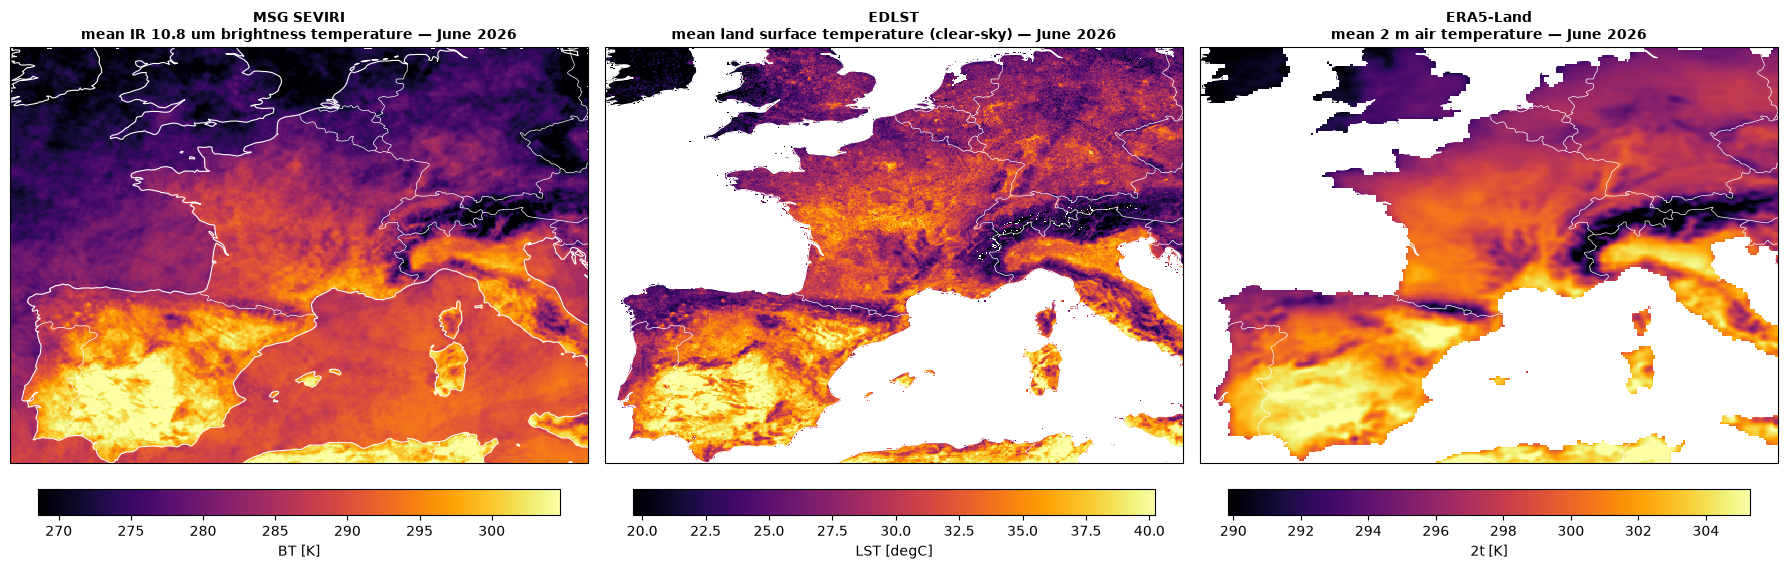

In [72]:
# The monthly means live on the time=1 slice of the aggregated cube - shown side by side
panels = [
    (mean_cube_data["msg_seviri_native_format_ir_10.8"].isel(time=0),
     "MSG SEVIRI\nmean IR 10.8 um brightness temperature", "BT [K]"),
    (mean_cube_data["metop_polar-orbiting_s_LST"].isel(time=0),
     "EDLST\nmean land surface temperature (clear-sky)", "LST [degC]"),
    (mean_cube_data["era5_2t"].isel(time=0),
     "ERA5-Land\nmean 2 m air temperature", "2t [K]"),
]

fig, axes = plt.subplots(
    1, 3, figsize=(18, 5.5), subplot_kw={"projection": ccrs.PlateCarree()}
)
for ax, (data_2d, title, cbar_label) in zip(axes, panels):
    # Same styling as plot_temperature_map, in panel form
    vmin = float(np.nanpercentile(data_2d.values, 2))
    vmax = float(np.nanpercentile(data_2d.values, 98))
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    im = ax.pcolormesh(
        data_2d["lon"].values, data_2d["lat"].values, data_2d.values,
        cmap="inferno", vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), shading="auto",
    )
    ax.coastlines(resolution="50m", linewidth=0.8, color="white")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="white")
    ax.set_title(f"{title} — June {YEAR}", fontsize=10, fontweight="bold")
    plt.colorbar(im, ax=ax, label=cbar_label, orientation="horizontal", pad=0.05, shrink=0.9)

plt.tight_layout()
plt.show()


### Verification plot: the three aligned sources side by side

The two features (MSG brightness temperature, EDLST surface temperature) and the label (ERA5-Land
air temperature) on the shared grid, drawn as three stacked planes over the same x,y footprint 
one grid, three co-registered layers: a real the cube, literally.

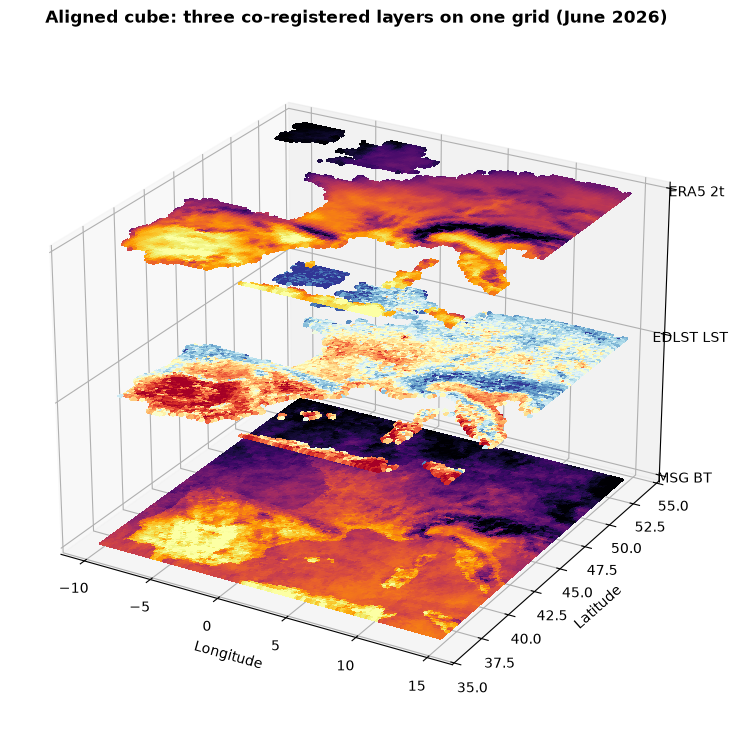

In [73]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection)
import matplotlib.colors as mcolors

# The aligned cube is one dataset with three variables on identical pixels. Drawing them as
# three planes over the same x,y footprint shows that literally: one grid, three stacked layers.
cube = mean_cube_data
msg_var, edlst_var, era5_var = (
    "msg_seviri_native_format_ir_10.8",
    "metop_polar-orbiting_s_LST",
    "era5_2t",
)

# 1. Pull each layer to Celsius (EDLST already in °C) and downsample for a responsive 3D render
step = 3  # draw every 3rd pixel: enough detail, far lighter to render
lon2d, lat2d = np.meshgrid(cube["lon"].values[::step], cube["lat"].values[::step])

layers = [
    (cube[msg_var].isel(time=0, drop=True).values[::step, ::step] - 273.15, "inferno",  0),
    (cube[edlst_var].isel(time=0, drop=True).values[::step, ::step],        "RdYlBu_r", 1),
    (cube[era5_var].isel(time=0, drop=True).values[::step, ::step] - 273.15, "inferno", 2),
]

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

z_gap = 1.0  # vertical spacing between planes
for data, cmap_name, z in layers:
    # 2. Normalize each layer by its own 2-98 percentile so structure is visible per band
    norm = mcolors.Normalize(vmin=np.nanpercentile(data, 2), vmax=np.nanpercentile(data, 98))
    colors = plt.get_cmap(cmap_name)(norm(data))
    colors[np.isnan(data)] = [0, 0, 0, 0]   # transparent where there is no data

    # 3. Lay the layer flat at its own height, colored by the field
    zplane = np.full(lon2d.shape, z * z_gap)
    ax.plot_surface(lon2d, lat2d, zplane, facecolors=colors,
                    rstride=1, cstride=1, shade=False, antialiased=False)

ax.set_zticks([0, z_gap, 2 * z_gap])
ax.set_zticklabels(["MSG BT", "EDLST LST", "ERA5 2t"])
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Aligned cube: three co-registered layers on one grid (June {YEAR})",
             fontweight="bold")
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "aligned_cube_3d.png"), dpi=150, bbox_inches="tight")
plt.show()

### Traceability: the cube's processing history

Every DEFAIR operation leaves a written trace. Each time a dataset is read or transformed,
DEFAIR appends a line to its `history` attribute, a standard metadata field (part of the CF
conventions widely used in climate and satellite data), recording when the operation ran,
which plugin did it, and with which exact parameters. The cell below prints that record for
our cube: you can read, step by step, how it was built.

One detail to interpret it correctly: after several datasets are merged into one cube, the
cube keeps **one** history, the chain of its *base* dataset (here MSG, the first argument of
the alignment call). The EDLST and ERA5 stacks each carry their own complete history in their
own objects, but those chains are not copied into the merged cube. So the printout below
documents the MSG branch end to end; for the full lineage of the other two sources, print
`edlst_stack.data.attrs["history"]` or `era5_stack.data.attrs["history"]`.

In [74]:
# Traceability: the cube carries its own processing chain (CF history convention)
print(mean_cube_data.attrs.get("history", "No history attribute found"))

2026-07-28T10:52:51.650834+00:00: Read operation [DEFAIR v0.3.0rc5:MSG15NativeReaderPlugin, channels=None, source='s3://datalake-demo-data/defair-demo-data/msg/20...']
2026-07-28T10:52:53.784605+00:00: Transform operation [DEFAIR v0.3.0rc5:ContentFilterPlugin, include_vars=['ir_10.8'], exclude_vars=None, squeeze_dims=None]
2026-07-28T10:52:53.803112+00:00: Transform operation [DEFAIR v0.3.0rc5:SpatialFilterPlugin, lat_min=36.0, lat_max=54.0, lon_min=-10.0, lon_max=15.0, polygon=None, drop=True, allow_partial=True, coordinate_group=None]
2026-07-28T10:53:12.185056+00:00: Transform operation [DEFAIR v0.3.0rc5:Reprojection, target=ReferenceGrid(crs=<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, transform=Affine(0.05, 0.0, -10.0,


## Machine learning: statistical mapping to air temperature

The model does one thing: a direct statistical mapping from the two satellite features to the
ERA5-Land air temperature label, per pixel, on the June-mean cube, the physics of the
surface-to-air relationship is implicitly absorbed into parameters learned from the data.
**Anti-circularity:** the feature matrix is built only from MSG and EDLST; ERA5-Land
contributes only the target. Since ERA5-Land is land-only, ocean pixels are dropped, which
defines the terrestrial domain of the problem.

Split for validation **spatially**: neighbouring pixels are strongly autocorrelated, so a random pixel-wise split
would leak information and inflate the metrics. Instead the area is divided into longitude
strips, and whole strips go to either train or validation (~75/25).

The model is a **Random Forest**: an average of many decision trees, each trained on a random
subset of the data. It captures a surface-to-air relationship that varies across the region
(coast vs. inland, different regimes) without being told the functional form. 

In [75]:
# 1. Flatten the aligned cube into one row per pixel: two features (x1, x2) and one label (y)
lat_2d, lon_2d = np.meshgrid(mean_cube_data["lat"].values, mean_cube_data["lon"].values, indexing="ij")

pixel_table = xr.Dataset(
    {
        "msg_bt": mean_cube_data["msg_seviri_native_format_ir_10.8"].isel(time=0, drop=True) - 273.15,
        "edlst_lst": mean_cube_data["metop_polar-orbiting_s_LST"].isel(time=0, drop=True),
        "era5_t2m": mean_cube_data["era5_2t"].isel(time=0, drop=True) - 273.15,
    }
).to_dataframe().reset_index()

# Keep only pixels where all three variables are valid (the land domain)
pixel_table = pixel_table.dropna(subset=["msg_bt", "edlst_lst", "era5_t2m"])
print(f"Valid land pixels: {len(pixel_table):,} of {mean_cube_data.sizes['lat'] * mean_cube_data.sizes['lon']:,}")

# 2. Spatial block split: whole longitude strips go to train or validation, never mixed pixels
N_STRIPS = 10
VALIDATION_FRACTION = 0.25

strip_edges = np.linspace(LON_MIN, LON_MAX, N_STRIPS + 1)
pixel_table["strip"] = np.digitize(pixel_table["lon"], strip_edges[1:-1])

# Hold out every 4th strip for validation (regular spacing avoids bias toward one region)
n_val_strips = max(1, round(N_STRIPS * VALIDATION_FRACTION))
val_strips = np.linspace(0, N_STRIPS - 1, n_val_strips, dtype=int)
pixel_table["split"] = np.where(pixel_table["strip"].isin(val_strips), "validation", "train")

train_df = pixel_table[pixel_table["split"] == "train"]
val_df = pixel_table[pixel_table["split"] == "validation"]
print(f"Train pixels:      {len(train_df):,} ({100 * len(train_df) / len(pixel_table):.1f}%)")
print(f"Validation pixels: {len(val_df):,} ({100 * len(val_df) / len(pixel_table):.1f}%)")

Valid land pixels: 98,648 of 180,000
Train pixels:      82,355 (83.5%)
Validation pixels: 16,293 (16.5%)


### Random Forest regression

A Random Forest is a simple non-linear model: it averages many decision trees, each trained on a
random subset of the data. Unlike the linear baseline it can capture a surface to air relationship
that varies across the region (coast vs. inland, different soil moisture regimes) without being
told the functional form. It is used here with modest settings:  the goal is a working, honest
estimate, not a heavily tuned model. Just demonstration purposes

In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

feature_cols = ["msg_bt", "edlst_lst"]
label_col = "era5_t2m"

X_train, y_train = train_df[feature_cols], train_df[label_col]
X_val, y_val = val_df[feature_cols], val_df[label_col]


def evaluate(model, X, y_true, label):
    """Print RMSE, MAE, R2 and mean bias for a model's predictions."""
    y_pred = model.predict(X)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    bias = (y_pred - y_true).mean()

    print(f"{label}")
    print(f"  RMSE: {rmse:.2f} degC")
    print(f"  MAE:  {mae:.2f} degC")
    print(f"  R2:   {r2:.3f}")
    print(f"  Bias: {bias:+.2f} degC")
    return y_pred


# n_estimators: number of trees; random_state fixes the result so it is reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_val_pred = evaluate(rf_model, X_val, y_val, "Random Forest — validation")

Random Forest — validation
  RMSE: 2.34 degC
  MAE:  1.73 degC
  R2:   0.615
  Bias: -1.07 degC


## Results

### Estimated air temperature map

The trained Random Forest is applied to every valid land pixel to produce the June-mean 2 m air
temperature estimated from the two satellite features alone. The flat per-pixel predictions are
placed back onto the 360×500 grid for mapping.

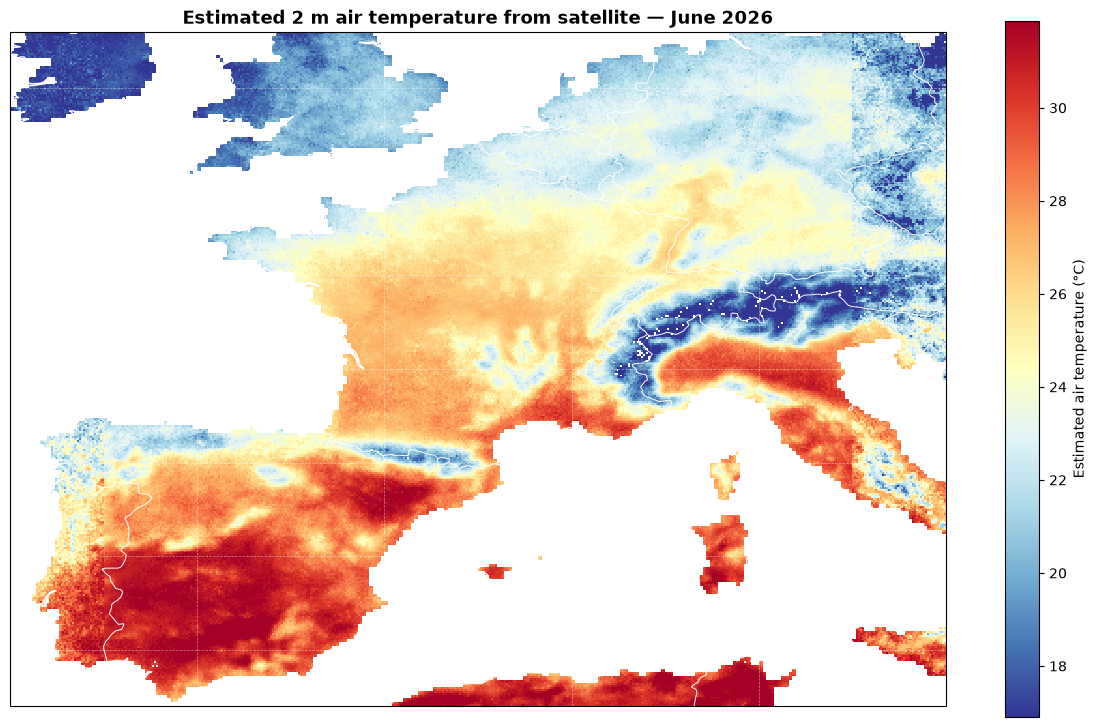

In [77]:
# Predict on all valid land pixels, then place the predictions back on the 2D grid
pixel_table = pixel_table.copy()
pixel_table["t2m_predicted"] = rf_model.predict(pixel_table[feature_cols])

# Empty grid (NaN everywhere), then fill it at the (lat, lon) of each predicted pixel
grid_shape = (mean_cube_data.sizes["lat"], mean_cube_data.sizes["lon"])
predicted_grid = xr.DataArray(
    np.full(grid_shape, np.nan),
    dims=["lat", "lon"],
    coords={"lat": mean_cube_data["lat"], "lon": mean_cube_data["lon"]},
)
predicted_grid.loc[
    dict(lat=xr.DataArray(pixel_table["lat"].values, dims="points"),
         lon=xr.DataArray(pixel_table["lon"].values, dims="points"))
] = pixel_table["t2m_predicted"].values

plot_temperature_map(
    predicted_grid,
    f"Estimated 2 m air temperature from satellite — June {YEAR}",
    "Estimated air temperature (°C)",
    cmap="RdYlBu_r",
)

### Spatial diagnostic: estimated minus ERA5-Land

The difference map (estimated − ERA5-Land label) shows where the satellite-only estimate is
warmer or cooler than the reanalysis. Note that this map includes the training pixels, so it is
a spatial diagnostic of model behaviour, not an independent error estimate — the honest error
figures are the validation-strip metrics above.

Difference (estimated - ERA5): mean=-0.18 degC, std=1.07, min=-10.90, max=+5.86


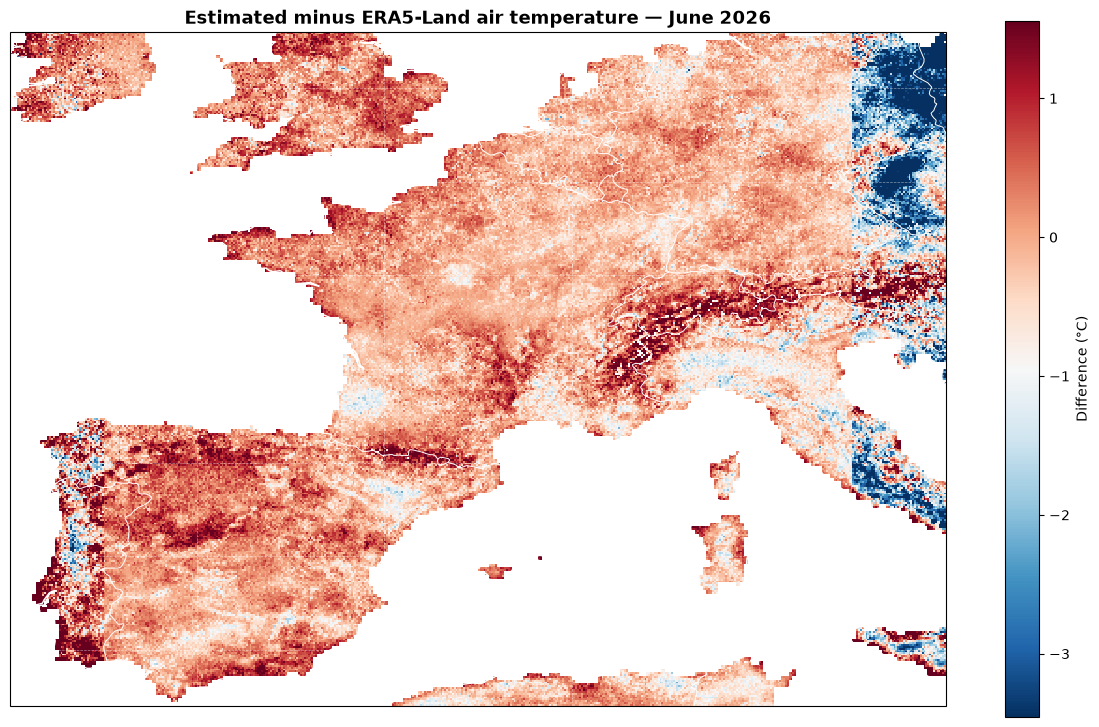

In [78]:
# Difference between the RF estimate and the ERA5-Land label, on the same grid
era5_grid = mean_cube_data[era5_var].isel(time=0, drop=True) - 273.15  # K -> degC
difference_grid = predicted_grid - era5_grid

print(f"Difference (estimated - ERA5): mean={float(difference_grid.mean()):+.2f} degC, "
      f"std={float(difference_grid.std()):.2f}, "
      f"min={float(difference_grid.min()):+.2f}, max={float(difference_grid.max()):+.2f}")

plot_temperature_map(
    difference_grid,
    f"Estimated minus ERA5-Land air temperature — June {YEAR}",
    "Difference (°C)",
    cmap="RdBu_r",
)

## Conclusions


**What the condensed formulation demonstrates about DEFAIR:**

- **Multi-file (wildcard) reading.** A month of MSG scenes and a month of ERA5-Land GRIBs are
  each opened in a single `Dataset.from_source` call: the glob is expanded server-side against
  the S3 bucket, the files are read in parallel, and the scenes are concatenated along `time`.
  Thirty-iteration acquisition loops become one line per source.
- **The AlignmentPlugin does the geometric heavy lifting.** The three stacks enter the alignment
  exactly as their readers deliver them , geostationary, global sinusoidal, global lat/lon — and
  a single call reprojects each stack onto the target grid, aligns the time axes, and merges the
  variables. The per-source reprojection steps of the classic formulation are absorbed, and each
  source is wrped once as a stack rather than thirty times as daily fields. The wrap is
  output-driven, so the global extents cost nothing.
- **A pinned `ReferenceGrid` makes the pipeline deterministic.** Declaring the output grid
  explicitly, CRS, affine transform, pixel dimensions, guarantees pixel-identical results
  across runs, and skips the framework's per-variable geometry probing entirely. Both properties
  were verified: the pinned-grid cube is bit-identical to the auto-computed one.
- **One temporal aggregation on the cube.** Averaging the merged daily cube is numerically
  equivalent to averaging each source before merging, so three `temporal_aggregate`
  calls collapse into one.
- **A bucket-only workflow.** With the raw-data cache in place, the notebook runs end to end
  with S3 credentials alone, no catalogue queries, no download cycles, no HDA authentication,
  in about five minutes from raw files to validated model.